In [ ]:
%pip install -r requirements.txt

  Using cached fsspec-2024.3.1-py3-none-any.whl.metadata (6.8 kB)
Using cached fsspec-2024.3.1-py3-none-any.whl (171 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.6.0
ERROR: Cannot uninstall fsspec 2023.6.0, RECORD file not found. You might be able to recover from this via: 'pip install --force-reinstall --no-deps fsspec==2023.6.0'.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Loading the Data:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
# Read the CSV file using pandas from the S3 bucket
bucket_name = 'ml-hr-data'
file_name = 'ml_hr_data.csv'
url = 'https://{bucket_name}.s3.amazonaws.com/{file_name}'
df = pd.read_csv(url.format(bucket_name=bucket_name, file_name=file_name))
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [ ]:
df.columns
df.shape
df.info


<bound method DataFrame.info of        employee_id         department     region         education gender  \
0            65438  Sales & Marketing   region_7  Master's & above      f   
1            65141         Operations  region_22        Bachelor's      m   
2             7513  Sales & Marketing  region_19        Bachelor's      m   
3             2542  Sales & Marketing  region_23        Bachelor's      m   
4            48945         Technology  region_26        Bachelor's      m   
...            ...                ...        ...               ...    ...   
54803         3030         Technology  region_14        Bachelor's      m   
54804        74592         Operations  region_27  Master's & above      f   
54805        13918          Analytics   region_1        Bachelor's      m   
54806        13614  Sales & Marketing   region_9               NaN      m   
54807        51526                 HR  region_22        Bachelor's      m   

      recruitment_channel  no_of_trainings 

In [ ]:
#Checking for Null Values

In [ ]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [ ]:
#Data Visualization:

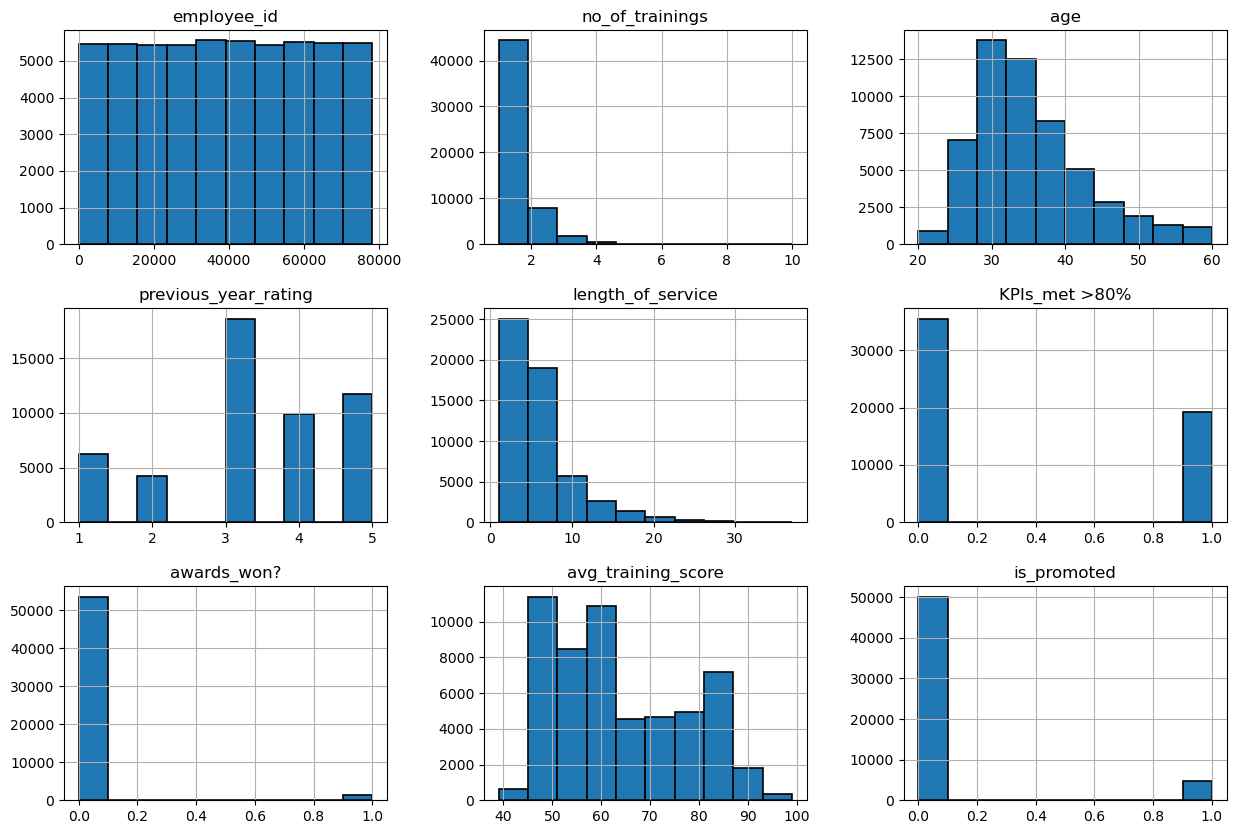

In [ ]:
# Visulazing the distibution of the data for every feature
df.hist(edgecolor='black', linewidth=1.2, figsize=(15, 10));

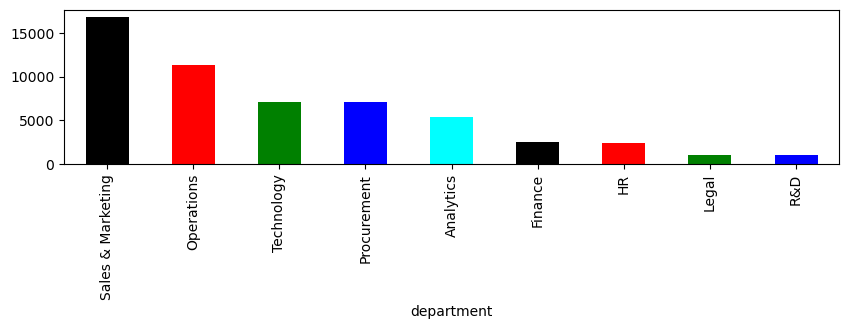

In [ ]:
# visualizing the different groups in the dataset
plt.subplots(figsize=(10,2))
df['department'].value_counts(normalize = True)
df['department'].value_counts(dropna = False).plot.bar(color=['black', 'red', 'green', 'blue', 'cyan'])
plt.show()

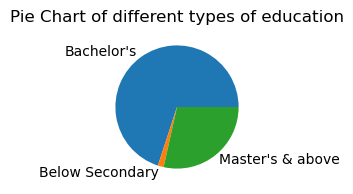

In [ ]:
# Prepare Data
education_df = df.groupby('education').size()
# Make the plot with pandas
education_df.plot(kind='pie', subplots=True, figsize=(10, 2))
plt.title("Pie Chart of different types of education")
plt.ylabel("")
plt.show()

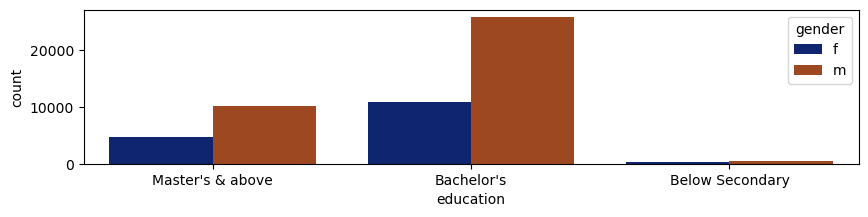

In [ ]:
plt.subplots(figsize=(10,2))
sns.countplot(x = 'education', data = df, hue = 'gender', palette = 'dark')
plt.show()

Text(0.5, 1.0, 'Distribution of Age of Employees')

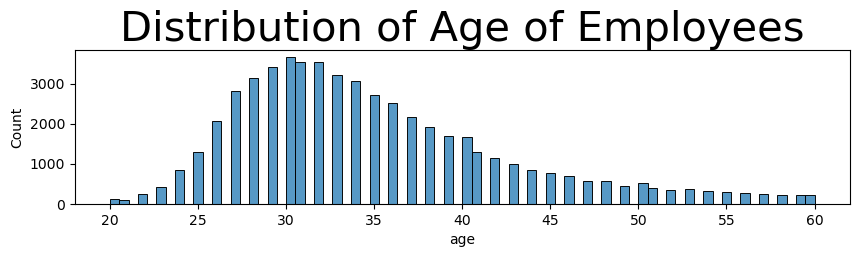

In [ ]:
plt.subplots(figsize=(10,2))
sns.histplot(df['age'])
plt.title('Distribution of Age of Employees', fontsize = 30)

/tmp/ipykernel_104/3123457173.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['length_of_service'], color = 'green')


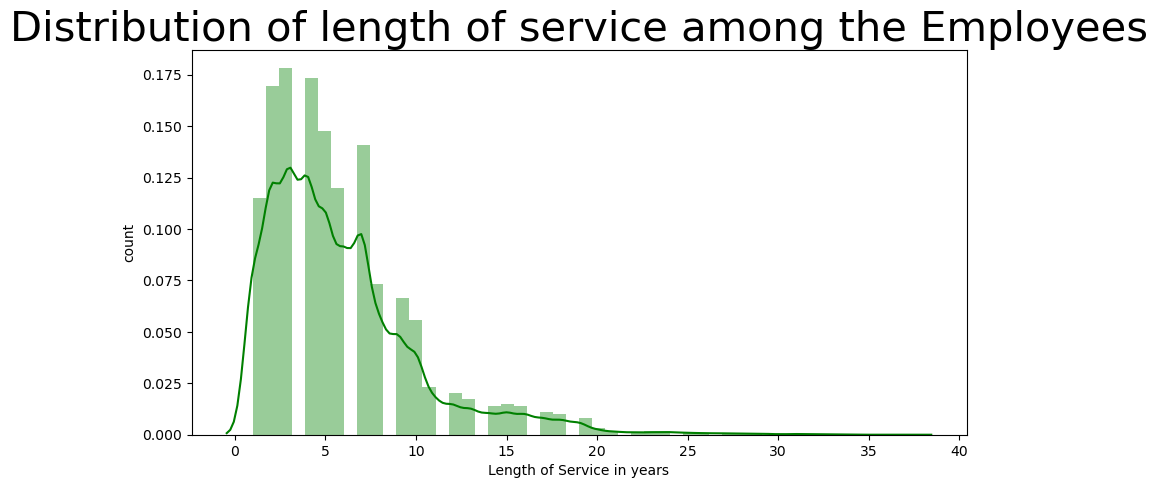

In [ ]:
# checking the distribution of length of service
plt.subplots(figsize=(10,5))
sns.distplot(df['length_of_service'], color = 'green')
plt.title('Distribution of length of service among the Employees', fontsize = 30)
plt.xlabel('Length of Service in years')
plt.ylabel('count')
plt.show()

In [ ]:
#Data Pre-processing

In [ ]:
import os
import joblib
from sklearn.model_selection import train_test_split
from sagemaker.remote_function import remote

os.environ["SAGEMAKER_USER_CONFIG_OVERRIDE"] = os.getcwd()

@remote(keep_alive_period_in_seconds=3600, job_name_prefix="amzn-sm-btd-preprocess")
def preprocess(df):

    #filling missing values
    df['education'].fillna(df['education'].mode()[0], inplace = True)
    df['previous_year_rating'].fillna(1, inplace = True)
    # again checking if there is any Null value left in the data
    df.isnull().sum().sum()

    # removing the employee_id column
    df = df.drop(['employee_id'], axis = 1)
    df.columns

    # Extract features (X) and labels (y)
    X = df.iloc[:, :-1] # Selecting all columns except the last one
    y = df.iloc[:, -1] # Selecting only the last column
    print("Shape of x:", X.shape)
    print("Shape of y:", y.shape)

    X = pd.get_dummies(X)
    X.columns

    # needed to install this in saggemaker for some reason...
    !pip install imbalanced-learn

    #from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # checking the sizes of the sample data
    print("Size of x-sample :", X_resampled.shape)
    print("Size of y-sample :", y_resampled.shape)

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

    # Split training data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

    print("Shape of X_train: ", X_train.shape)
    print("Shape of X_val: ", X_val.shape)
    print("Shape of X_test: ", X_test.shape)
    print("Shape of y_train: ", y_train.shape)
    print("Shape of y_val: ", y_val.shape)
    print("Shape of y_test: ", y_test.shape)

    #standard scaling
    from sklearn.preprocessing import StandardScaler
    sc = StandardScaler()
    featurizer_model = sc.fit(X_train)
    X_train = sc.fit_transform(X_train)
    X_val = sc.transform(X_val)
    X_test = sc.transform(X_test)
    featurizer_model

    model_file_path="/opt/ml/model/sklearn_model.joblib"
    #model_file_path="./sklearn_model.joblib"
    os.makedirs(os.path.dirname(model_file_path), exist_ok=True)
    joblib.dump(featurizer_model, model_file_path)

    return X_train, y_train, X_val, y_val, X_test, y_test, featurizer_model

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.Dependencies
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.PreExecutionCommands
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.IncludeLocalWorkDir
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.CustomFileFilter.IgnoreNamePatterns
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.InstanceType


In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test, featurizer_model = preprocess(df)

2024-05-01 20:19:32,823 sagemaker.remote_function INFO     Serializing function code to s3://sagemaker-us-east-1-619694357064/amzn-sm-btd-preprocess-2024-05-01-20-19-32-823/function
2024-05-01 20:19:33,027 sagemaker.remote_function INFO     Serializing function arguments to s3://sagemaker-us-east-1-619694357064/amzn-sm-btd-preprocess-2024-05-01-20-19-32-823/arguments
2024-05-01 20:19:33,514 sagemaker.remote_function INFO     Copied user workspace to '/tmp/tmpultsur01/temp_workspace/sagemaker_remote_function_workspace'
2024-05-01 20:19:33,517 sagemaker.remote_function INFO     Copied dependencies file at './requirements.txt' to '/tmp/tmpultsur01/temp_workspace/sagemaker_remote_function_workspace/requirements.txt'
2024-05-01 20:19:33,518 sagemaker.remote_function INFO     Generated pre-execution script from commands to '/tmp/tmpultsur01/temp_workspace/sagemaker_remote_function_workspace/pre_exec.sh'
2024-05-01 20:19:33,531 sagemaker.remote_function INFO     Successfully created workdir a

2024-05-01 20:19:33 Starting - Starting the training job...
2024-05-01 20:19:49 Starting - Preparing the instances for training...
2024-05-01 20:20:20 Downloading - Downloading input data...
2024-05-01 20:20:45 Downloading - Downloading the training image......
2024-05-01 20:21:41 Training - Training image download completed. Training in progress.INFO: CONDA_PKGS_DIRS is set to '/opt/ml/sagemaker/warmpoolcache/sm_remotefunction_user_dependencies_cache/conda/pkgs'
INFO: PIP_CACHE_DIR is set to '/opt/ml/sagemaker/warmpoolcache/sm_remotefunction_user_dependencies_cache/pip'
INFO: Bootstraping runtime environment.
2024-05-01 20:21:50,927 sagemaker.remote_function INFO     Successfully unpacked workspace archive at '/home/sagemaker-user'.
2024-05-01 20:21:50,927 sagemaker.remote_function INFO     Running pre-execution commands in '/home/sagemaker-user/sagemaker_remote_function_workspace/pre_exec.sh'
2024-05-01 20:21:50,936 sagemaker.remote_function INFO     Running command: '/opt/conda/bin/

In [ ]:
# Model Training

In [ ]:
from xgboost.sklearn import XGBClassifier
from sklearn.metrics import accuracy_score

from sagemaker.remote_function import remote

@remote(keep_alive_period_in_seconds=3600, job_name_prefix="amzn-sm-btd-train")
def train(X_train, y_train, X_val, y_val, X_test, y_test):

    #XGBoost CLassifier
    model = XGBClassifier()
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    #train_accuracy = accuracy_score(y_train, y_train_pred)
    #val_accuracy = accuracy_score(y_val, y_val_pred)
    #test_accuracy = accuracy_score(y_test, y_test_pred)
    #print("Training Accuracy :", train_accuracy)
    #print("Validation Accuracy :", val_accuracy)
    #print("Testing Accuracy :", test_accuracy)

    model_file_path="/opt/ml/model/xgboost_model.bin"
    os.makedirs(os.path.dirname(model_file_path), exist_ok=True)
    model.save_model(model_file_path)

    return model

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.Dependencies
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.PreExecutionCommands
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.IncludeLocalWorkDir
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.CustomFileFilter.IgnoreNamePatterns
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.RemoteFunction.InstanceType


In [ ]:
booster = train(X_train, y_train, X_val, y_val, X_test, y_test)

2024-05-01 20:27:16,620 sagemaker.remote_function INFO     Serializing function code to s3://sagemaker-us-east-1-619694357064/amzn-sm-btd-train-2024-05-01-20-27-16-618/function
2024-05-01 20:27:16,789 sagemaker.remote_function INFO     Serializing function arguments to s3://sagemaker-us-east-1-619694357064/amzn-sm-btd-train-2024-05-01-20-27-16-618/arguments
2024-05-01 20:27:17,965 sagemaker.remote_function INFO     Copied user workspace to '/tmp/tmp99zxd08d/temp_workspace/sagemaker_remote_function_workspace'
2024-05-01 20:27:17,970 sagemaker.remote_function INFO     Copied dependencies file at './requirements.txt' to '/tmp/tmp99zxd08d/temp_workspace/sagemaker_remote_function_workspace/requirements.txt'
2024-05-01 20:27:17,972 sagemaker.remote_function INFO     Generated pre-execution script from commands to '/tmp/tmp99zxd08d/temp_workspace/sagemaker_remote_function_workspace/pre_exec.sh'
2024-05-01 20:27:18,008 sagemaker.remote_function INFO     Successfully created workdir archive at 

2024-05-01 20:27:18 Starting - Starting the training job...
2024-05-01 20:27:34 Starting - Preparing the instances for training...
2024-05-01 20:28:07 Downloading - Downloading input data...
2024-05-01 20:28:27 Downloading - Downloading the training image......
2024-05-01 20:29:22 Training - Training image download completed. Training in progress.INFO: CONDA_PKGS_DIRS is set to '/opt/ml/sagemaker/warmpoolcache/sm_remotefunction_user_dependencies_cache/conda/pkgs'
INFO: PIP_CACHE_DIR is set to '/opt/ml/sagemaker/warmpoolcache/sm_remotefunction_user_dependencies_cache/pip'
INFO: Bootstraping runtime environment.
2024-05-01 20:29:32,379 sagemaker.remote_function INFO     Successfully unpacked workspace archive at '/home/sagemaker-user'.
2024-05-01 20:29:32,379 sagemaker.remote_function INFO     Running pre-execution commands in '/home/sagemaker-user/sagemaker_remote_function_workspace/pre_exec.sh'
2024-05-01 20:29:32,389 sagemaker.remote_function INFO     Running command: '/opt/conda/bin/

In [ ]:
booster

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)